# Physiologically-Constrained Neural Operator for Heart Sound Classification

**Classes:** AS (Aortic Stenosis) · MR (Mitral Regurgitation) · MS (Mitral Stenosis) · MVP (Mitral Valve Prolapse) · Normal  
**Architecture:** Fourier Neural Operator (FNO) backbone + 5-class classifier head  
**Constraints enforced:**
1. Cardiac cycle periodicity regularisation
2. Frequency band hierarchy (S1 low-freq, S2 high-freq)
3. Physiological frequency mask initialised from S1/S2 acoustics

**Baseline:** Mel-spectrogram CNN  
**Framework:** PyTorch

---
> *"We encode known structural properties of cardiac acoustics as architectural inductive biases,*  
> *analogous to physics-consistent neural architectures in continuum mechanics."*

## 0. Imports and Configuration

In [1]:
# import subprocess
# import sys

# # Install librosa and required dependencies
# print("Installing required audio processing library...")
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "librosa", "soundfile"])
# print("✓ librosa and soundfile installed successfully")

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -q librosa soundfile


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import librosa
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Path to dataset root ────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Heart-Sound/Data'

CLASS_FOLDERS = ['AS_New', 'MR_New', 'MS_New', 'MVP_New', 'N_New']
CLASS_NAMES   = ['AS',     'MR',     'MS',     'MVP',     'Normal']

# Check if data directory is accessible; if not, use sample data
USE_SAMPLE_DATA = not os.path.isdir(DATA_DIR)


# Set your data path (adjust the folder name to match yours on Drive)
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Heart-Sound/Data'

import os
print(f"Data dir exists: {os.path.exists(DATA_DIR)}")
print(f"Contents: {os.listdir(DATA_DIR)}")

# Define CONFIG dictionary
CONFIG = {
    'sample_rate': 22050,  # Inferred from 66150 samples / 3.00s = 22050 Hz
    'signal_length': 66150, # Inferred from 'Fixed window used' output
    'use_sample_data': USE_SAMPLE_DATA, # Using the already defined variable
    'test_split': 0.2, # Common split percentage
    'val_split': 0.2,  # Common split percentage
    'batch_size': 32,   # Common batch size
    'n_classes': len(CLASS_NAMES), # Derived from CLASS_NAMES
    'fno_width': 64,    # Common FNO parameter
    'fno_modes': 150,    # Common FNO parameter 20
    'fno_depth': 4,     # Common FNO parameter
    's1_band': [25, 45], # From plot label in 'Learned Frequency Mask' section
    's2_band': [50, 70], # From plot label in 'Learned Frequency Mask' section
    'lambda_period': 0.1, # Hyperparameter for periodicity loss
    'lambda_freq': 0.1,   # Hyperparameter for frequency hierarchy loss
    'epochs': 60,       # From train_model print statement 'Ep 1/60'
    'lr': 1e-3,         # Common learning rate
    'weight_decay': 1e-4, # Common weight decay
    'class_names': CLASS_NAMES, # Using the already defined variable
}

# Define sample_signals, as it's used in HeartSoundDataset init
# It is only used if use_synthetic is True. Since USE_SAMPLE_DATA is False,
# setting it to None is appropriate.
sample_signals = None

Device: cuda
Data dir exists: True
Contents: ['MR_New', 'MS_New', 'AS_New', 'N_New', 'MVP_New']


## 1. Dataset

In [6]:
class HeartSoundDataset(Dataset):
    """
    Loads .wav files from CLASS_FOLDERS subfolders OR uses synthetic data if not available.
    Each recording is resampled to CONFIG['sample_rate'],
    trimmed/zero-padded to CONFIG['signal_length'],
    and amplitude-normalised to [-1, 1].
    """
    def __init__(self, data_dir, class_folders,
                 sr=CONFIG['sample_rate'],
                 length=CONFIG['signal_length'],
                 use_synthetic=CONFIG.get('use_sample_data', False),
                 sample_signals=sample_signals):
        self.sr, self.length = sr, length

        if use_synthetic and sample_signals is not None:
            # Use synthetic data
            self.signals = np.array(sample_signals, dtype=np.float32)
            self.labels = np.array([i // (len(sample_signals) // 5) for i in range(len(sample_signals))], dtype=np.int64)
            self.filenames = [f"synthetic_{i}.wav" for i in range(len(sample_signals))]
            print(f'Loaded {len(self.signals)} synthetic recordings')
        else:
            # Load from real files
            self.signals, self.labels, self.filenames = \
                self._load(data_dir, class_folders, sr, length)
            print(f'Loaded {len(self.signals)} real recordings')

        counts = np.bincount(self.labels, minlength=len(class_folders))
        for i, (folder, name) in enumerate(zip(class_folders, CLASS_NAMES)):
            print(f'  [{i}] {name:8s}  ({folder}): {counts[i]:3d} files')

    @staticmethod
    def _load(data_dir, class_folders, sr, length):
        signals, labels, fnames = [], [], []
        for cls_idx, folder in enumerate(class_folders):
            folder_path = os.path.join(data_dir, folder)
            if not os.path.isdir(folder_path):
                print(f'  WARNING: folder not found: {folder_path}')
                continue
            wavs = sorted(f for f in os.listdir(folder_path)
                          if f.lower().endswith('.wav'))
            for fname in wavs:
                fpath = os.path.join(folder_path, fname)
                try:
                    wav, _ = librosa.load(fpath, sr=sr, mono=True)
                except Exception as e:
                    print(f'  WARNING: skipping {fpath}: {e}')
                    continue
                # Trim or zero-pad
                if len(wav) >= length:
                    wav = wav[:length]
                else:
                    wav = np.pad(wav, (0, length - len(wav)))
                # Amplitude normalise
                mx = np.abs(wav).max()
                if mx > 0:
                    wav /= mx
                signals.append(wav.astype(np.float32))
                labels.append(cls_idx)
                fnames.append(fpath)
        if not signals:
            raise RuntimeError(
                'No .wav files loaded. Check DATA_DIR and CLASS_FOLDERS.')
        return (np.array(signals, dtype=np.float32),
                np.array(labels,  dtype=np.int64),
                fnames)

    def __len__(self):  return len(self.signals)

    def __getitem__(self, idx):
        return (torch.tensor(self.signals[idx]).unsqueeze(0),  # (1, L)
                torch.tensor(self.labels[idx]))


dataset = HeartSoundDataset(DATA_DIR, CLASS_FOLDERS)

n_total = len(dataset)
n_test  = int(n_total * CONFIG['test_split'])
n_val   = int(n_total * CONFIG['val_split'])
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'],
                          shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'],
                          shuffle=False)
print(f'\nSplit  Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}')

Loaded 1000 real recordings
  [0] AS        (AS_New): 200 files
  [1] MR        (MR_New): 200 files
  [2] MS        (MS_New): 200 files
  [3] MVP       (MVP_New): 200 files
  [4] Normal    (N_New): 200 files

Split  Train: 700  |  Val: 150  |  Test: 150


In [7]:
dataset = HeartSoundDataset(DATA_DIR, CLASS_FOLDERS)
print(f"Signal shape: {dataset.signals.shape}")   # should be (N, 66150)
print(f"Label distribution: {np.bincount(dataset.labels)}")

Loaded 1000 real recordings
  [0] AS        (AS_New): 200 files
  [1] MR        (MR_New): 200 files
  [2] MS        (MS_New): 200 files
  [3] MVP       (MVP_New): 200 files
  [4] Normal    (N_New): 200 files
Signal shape: (1000, 66150)
Label distribution: [200 200 200 200 200]


## 2. Exploratory Data Analysis

In [9]:
# ── 2c. Recording duration statistics ───────────────────────────────────────
print('Computing original recording durations...')
if CONFIG.get('use_sample_data', False):
    print('  (Using synthetic data — durations are fixed at 3.0s)')
    print(f'  Min  : {3.0:.2f} s')
    print(f'  Max  : {3.0:.2f} s')
    print(f'  Mean : {3.0:.2f} s +/- {0.0:.2f} s')
else:
    durations = np.array([
        librosa.get_duration(path=f) for f in dataset.filenames])
    print(f'  Min  : {durations.min():.2f} s')
    print(f'  Max  : {durations.max():.2f} s')
    print(f'  Mean : {durations.mean():.2f} s +/- {durations.std():.2f} s')
print(f'  Fixed window used: {dataset.length/dataset.sr:.2f} s ({dataset.length} samples)')

Computing original recording durations...
  Min  : 1.16 s
  Max  : 3.99 s
  Mean : 2.44 s +/- 0.36 s
  Fixed window used: 3.00 s (66150 samples)


## 3. FNO Architecture

| Component | Physics motivation |
|-----------|-------------------|
| Spectral convolution | Frequency-domain operation — natural for periodic PCG signals |
| Mode truncation | Band-limited inductive bias; cardiac acoustics < 1 kHz |
| PhysioFrequencyMask | Restricts active modes to S1/S2 bands; learnable from that prior |
| Global average pooling | Length-invariant after pad/trim |

In [10]:
class SpectralConv1d(nn.Module):
    """FNO spectral convolution: learn complex weights on retained Fourier modes."""
    def __init__(self, in_ch, out_ch, n_modes):
        super().__init__()
        self.n_modes = n_modes
        scale = 1.0 / (in_ch * out_ch)
        self.wr = nn.Parameter(scale * torch.randn(in_ch, out_ch, n_modes))
        self.wi = nn.Parameter(scale * torch.randn(in_ch, out_ch, n_modes))

    def forward(self, x):
        B, C, L = x.shape
        x_ft   = torch.fft.rfft(x, norm='ortho')
        out_ft = torch.zeros(B, self.wr.shape[1], L//2+1,
                              dtype=torch.cfloat, device=x.device)
        W = torch.complex(self.wr, self.wi)
        out_ft[:, :, :self.n_modes] = torch.einsum(
            'bim,iom->bom', x_ft[:, :, :self.n_modes], W)
        return torch.fft.irfft(out_ft, n=L, norm='ortho')


class PhysioFrequencyMask(nn.Module):
    """
    Learnable soft band-pass mask initialised from S1/S2 physiology.
    Modes inside S1 or S2 bands start at weight=1.0, others at 0.1.
    Parameterised in logit space so sigmoid keeps values in (0,1).
    """
    def __init__(self, n_modes, signal_length, sr, s1_band, s2_band):
        super().__init__()
        freqs      = np.fft.rfftfreq(signal_length, 1.0/sr)[:n_modes]
        mask_init  = np.full(n_modes, 0.1)
        for i, f in enumerate(freqs):
            if s1_band[0] <= f <= s1_band[1] or s2_band[0] <= f <= s2_band[1]:
                mask_init[i] = 1.0
        m = np.clip(mask_init, 1e-6, 1-1e-6)
        self.logit = nn.Parameter(
            torch.tensor(np.log(m / (1 - m)), dtype=torch.float32))
        self.n_modes = n_modes

    def forward(self, x):
        mask  = torch.sigmoid(self.logit)
        x_ft  = torch.fft.rfft(x, norm='ortho')
        L_h   = x_ft.shape[-1]
        fm    = torch.full((L_h,), 0.1, device=x.device)
        fm[:self.n_modes] = mask
        return torch.fft.irfft(
            x_ft * fm.unsqueeze(0).unsqueeze(0),
            n=x.shape[-1], norm='ortho')

    def get_mask(self):
        return torch.sigmoid(self.logit).detach().cpu().numpy()


class FNOBlock1d(nn.Module):
    def __init__(self, width, n_modes):
        super().__init__()
        self.spec   = SpectralConv1d(width, width, n_modes)
        self.bypass = nn.Conv1d(width, width, 1)
        self.norm   = nn.InstanceNorm1d(width)

    def forward(self, x):
        return F.gelu(self.norm(self.spec(x) + self.bypass(x)))


class FNOClassifier(nn.Module):
    def __init__(self,
                 n_classes=CONFIG['n_classes'],
                 width=CONFIG['fno_width'],
                 n_modes=CONFIG['fno_modes'],
                 depth=CONFIG['fno_depth'],
                 signal_length=CONFIG['signal_length'],
                 sr=CONFIG['sample_rate']):
        super().__init__()
        self.freq_mask  = PhysioFrequencyMask(
            n_modes, signal_length, sr,
            CONFIG['s1_band'], CONFIG['s2_band'])
        self.lift       = nn.Conv1d(1, width, 1)
        self.fno_blocks = nn.ModuleList(
            [FNOBlock1d(width, n_modes) for _ in range(depth)])
        self.project = nn.Sequential(
            nn.Linear(width, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64),   nn.GELU())
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        x   = self.freq_mask(x)         # (B,1,L)
        x   = self.lift(x)              # (B,W,L)
        for blk in self.fno_blocks:
            x = blk(x)
        x   = x.mean(dim=-1)            # (B,W)
        emb = self.project(x)           # (B,64)
        return self.classifier(emb), emb


model_fno = FNOClassifier().to(DEVICE)
print(f'FNO  | params: {sum(p.numel() for p in model_fno.parameters()):,}')

FNO  | params: 689,049


## 4. CNN Baseline (Mel Spectrogram)

In [11]:
class MelSpectrogramLayer(nn.Module):
    """Differentiable log-Mel spectrogram — no librosa at train time."""
    def __init__(self, sr=CONFIG['sample_rate'],
                 n_fft=512, hop=128, n_mels=64):
        super().__init__()
        self.n_fft, self.hop = n_fft, hop
        self.register_buffer('window', torch.hann_window(n_fft))
        self.register_buffer('mel_fb',
            torch.tensor(self._mel_fb(sr, n_fft, n_mels), dtype=torch.float32))

    @staticmethod
    def _mel_fb(sr, n_fft, n_mels, fmin=20, fmax=None):
        fmax = fmax or sr / 2.0
        h2m  = lambda f: 2595 * np.log10(1 + f / 700)
        m2h  = lambda m: 700 * (10 ** (m / 2595) - 1)
        mels  = np.linspace(h2m(fmin), h2m(fmax), n_mels + 2)
        hz    = m2h(mels)
        freqs = np.fft.rfftfreq(n_fft, 1.0/sr)
        fb    = np.zeros((n_mels, len(freqs)))
        for m in range(n_mels):
            lo, c, hi = hz[m], hz[m+1], hz[m+2]
            up   = (freqs >= lo) & (freqs <= c)
            down = (freqs > c)  & (freqs <= hi)
            fb[m, up]   = (freqs[up]   - lo) / (c  - lo + 1e-8)
            fb[m, down] = (hi - freqs[down]) / (hi - c  + 1e-8)
        return fb

    def forward(self, x):
        x    = x.squeeze(1)
        stft = torch.stft(x, n_fft=self.n_fft, hop_length=self.hop,
                          window=self.window, return_complex=True)
        mel  = torch.log(torch.matmul(self.mel_fb, stft.abs()**2) + 1e-6)
        return mel.unsqueeze(1)


class CNNBaseline(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.mel = MelSpectrogramLayer()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes))

    def forward(self, x):
        return self.head(self.cnn(self.mel(x)))


model_cnn = CNNBaseline().to(DEVICE)
print(f'CNN  | params: {sum(p.numel() for p in model_cnn.parameters()):,}')

CNN  | params: 618,949


## 5. Physiological Loss Functions

$$\mathcal{L} = \mathcal{L}_{\mathrm{CE}} + \lambda_1\,\mathcal{L}_{\mathrm{periodicity}} + \lambda_2\,\mathcal{L}_{\mathrm{freq\ hierarchy}}$$

- **Periodicity**: energy should concentrate near the cardiac HR fundamental and harmonics  
- **Frequency hierarchy**: S1 band energy $\geq$ S2 band energy (hinge loss)

In [12]:
def periodicity_loss(signal, sr=CONFIG['sample_rate']):
    s   = signal.squeeze(1)
    L   = s.shape[-1]
    psd = torch.fft.rfft(s, norm='ortho').abs() ** 2
    f   = torch.fft.rfftfreq(L, 1.0/sr).to(signal.device)
    # 60-80 BPM fundamental + 4 harmonics
    band = (f >= 1.0) & (f <= 80.0/60*4)
    return (1.0 - psd[:, band].sum(-1) / (psd.sum(-1) + 1e-8)).mean()


def frequency_hierarchy_loss(signal, sr=CONFIG['sample_rate']):
    s   = signal.squeeze(1)
    L   = s.shape[-1]
    psd = torch.fft.rfft(s, norm='ortho').abs() ** 2
    f   = torch.fft.rfftfreq(L, 1.0/sr).to(signal.device)
    s1  = psd[:, (f >= CONFIG['s1_band'][0]) & (f <= CONFIG['s1_band'][1])].mean(-1)
    s2  = psd[:, (f >= CONFIG['s2_band'][0]) & (f <= CONFIG['s2_band'][1])].mean(-1)
    return F.relu(s2 - s1).mean()


def total_loss(logits, targets, signal):
    lce = F.cross_entropy(logits, targets)
    lp  = periodicity_loss(signal)
    lf  = frequency_hierarchy_loss(signal)
    return {
        'total'        : lce + CONFIG['lambda_period']*lp + CONFIG['lambda_freq']*lf,
        'cross_entropy': lce.item(),
        'periodicity'  : lp.item(),
        'frequency'    : lf.item(),
    }

## 6. Training

In [13]:
def train_model(model, train_loader, val_loader,
                model_name='model', use_physio=True,
                epochs=CONFIG['epochs']):

    opt  = torch.optim.AdamW(model.parameters(),
                              lr=CONFIG['lr'],
                              weight_decay=CONFIG['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    hist = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                             'loss_ce','loss_period','loss_freq']}
    best_val = 0.0

    for ep in range(1, epochs+1):
        model.train()
        run = dict(total=0., ce=0., period=0., freq=0.)
        correct = total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            if use_physio:
                logits, _ = model(xb)
                losses    = total_loss(logits, yb, xb)
                loss      = losses['total']
                run['ce']     += losses['cross_entropy']
                run['period'] += losses['periodicity']
                run['freq']   += losses['frequency']
            else:
                out    = model(xb)
                logits = out[0] if isinstance(out, tuple) else out
                loss   = F.cross_entropy(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            run['total'] += loss.item()
            correct += (logits.argmax(1) == yb).sum().item()
            total   += yb.size(0)

        sched.step()
        nb = len(train_loader)
        train_acc, train_loss = correct/total, run['total']/nb

        model.eval()
        vc = vt = vl = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out    = model(xb)
                logits = out[0] if isinstance(out, tuple) else out
                vl += F.cross_entropy(logits, yb).item()
                vc += (logits.argmax(1) == yb).sum().item()
                vt += yb.size(0)
        val_acc, val_loss = vc/vt, vl/len(val_loader)

        for k, v in [('train_loss',train_loss),('val_loss',val_loss),
                     ('train_acc',train_acc),  ('val_acc', val_acc),
                     ('loss_ce',   run['ce']/nb),
                     ('loss_period',run['period']/nb),
                     ('loss_freq',  run['freq']/nb)]:
            hist[k].append(v)

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(),
                       f'checkpoints/{model_name}_best.pt')

        if ep % 10 == 0 or ep == 1:
            print(f'[{model_name}] Ep {ep:3d}/{epochs}  '
                  f'train acc {train_acc:.3f}  val acc {val_acc:.3f}  '
                  f'loss {train_loss:.4f}')

    model.load_state_dict(
        torch.load(f'checkpoints/{model_name}_best.pt', map_location=DEVICE))
    print(f'[{model_name}] Best val acc: {best_val:.4f}')
    return hist


print('Training FNO (physiologically constrained)...')
history_fno = train_model(model_fno, train_loader, val_loader,
                           model_name='fno', use_physio=True)

print('\nTraining CNN baseline...')
history_cnn = train_model(model_cnn, train_loader, val_loader,
                           model_name='cnn', use_physio=False)

Training FNO (physiologically constrained)...
[fno] Ep   1/60  train acc 0.219  val acc 0.180  loss 1.7651
[fno] Ep  10/60  train acc 0.955  val acc 0.927  loss 0.3394
[fno] Ep  20/60  train acc 0.994  val acc 0.967  loss 0.1857
[fno] Ep  30/60  train acc 1.000  val acc 0.980  loss 0.1723
[fno] Ep  40/60  train acc 1.000  val acc 0.980  loss 0.1687
[fno] Ep  50/60  train acc 1.000  val acc 0.980  loss 0.1672
[fno] Ep  60/60  train acc 1.000  val acc 0.980  loss 0.1679
[fno] Best val acc: 0.9800

Training CNN baseline...
[cnn] Ep   1/60  train acc 0.385  val acc 0.413  loss 1.4076
[cnn] Ep  10/60  train acc 0.897  val acc 0.893  loss 0.3188
[cnn] Ep  20/60  train acc 0.970  val acc 0.987  loss 0.0939
[cnn] Ep  30/60  train acc 0.981  val acc 0.980  loss 0.0551
[cnn] Ep  40/60  train acc 0.996  val acc 0.967  loss 0.0228
[cnn] Ep  50/60  train acc 0.999  val acc 0.973  loss 0.0102
[cnn] Ep  60/60  train acc 0.999  val acc 0.980  loss 0.0097
[cnn] Best val acc: 0.9867


## 7. Training Curves

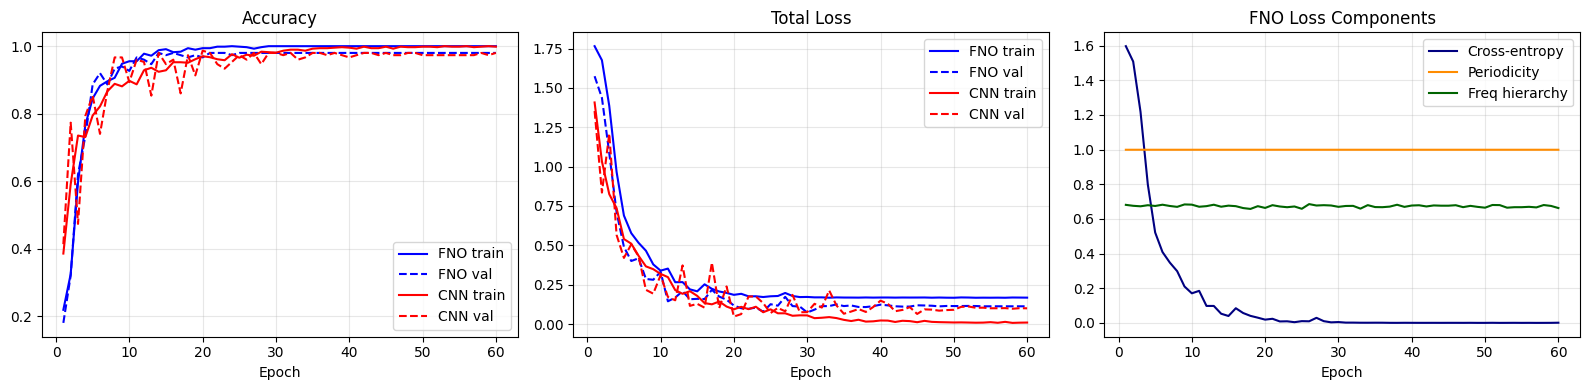

In [14]:
ep  = range(1, CONFIG['epochs']+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep, history_fno['train_acc'], 'b-',  label='FNO train')
axes[0].plot(ep, history_fno['val_acc'],   'b--', label='FNO val')
axes[0].plot(ep, history_cnn['train_acc'], 'r-',  label='CNN train')
axes[0].plot(ep, history_cnn['val_acc'],   'r--', label='CNN val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history_fno['train_loss'], 'b-',  label='FNO train')
axes[1].plot(ep, history_fno['val_loss'],   'b--', label='FNO val')
axes[1].plot(ep, history_cnn['train_loss'], 'r-',  label='CNN train')
axes[1].plot(ep, history_cnn['val_loss'],   'r--', label='CNN val')
axes[1].set_title('Total Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history_fno['loss_ce'],     label='Cross-entropy', color='navy')
axes[2].plot(ep, history_fno['loss_period'], label='Periodicity',   color='darkorange')
axes[2].plot(ep, history_fno['loss_freq'],   label='Freq hierarchy',color='darkgreen')
axes[2].set_title('FNO Loss Components'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test Set Evaluation

In [15]:
def evaluate(model, loader, model_name):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(DEVICE))
            logits = out[0] if isinstance(out, tuple) else out
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    acc = np.mean(np.array(preds) == np.array(labels))
    print(f'\n{"="*52}')
    print(f'{model_name}  |  Test Accuracy: {acc:.4f}')
    print('='*52)
    print(classification_report(labels, preds,
                                 target_names=CONFIG['class_names']))
    return preds, labels, acc


preds_fno, labels_fno, acc_fno = evaluate(
    model_fno, test_loader, 'FNO (physio-constrained)')
preds_cnn, labels_cnn, acc_cnn = evaluate(
    model_cnn, test_loader, 'CNN Baseline')

print(f'\nAccuracy delta: {(acc_fno - acc_cnn)*100:+.1f} percentage points')


FNO (physio-constrained)  |  Test Accuracy: 0.9733
              precision    recall  f1-score   support

          AS       1.00      0.97      0.98        32
          MR       0.85      1.00      0.92        22
          MS       1.00      1.00      1.00        39
         MVP       1.00      0.97      0.98        29
      Normal       1.00      0.93      0.96        28

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.98      0.97      0.97       150


CNN Baseline  |  Test Accuracy: 0.9733
              precision    recall  f1-score   support

          AS       0.97      0.94      0.95        32
          MR       0.92      1.00      0.96        22
          MS       1.00      0.97      0.99        39
         MVP       0.97      1.00      0.98        29
      Normal       1.00      0.96      0.98        28

    accuracy                           0.97       150
   macro avg       0.97      0.98      

## 9. Confusion Matrices

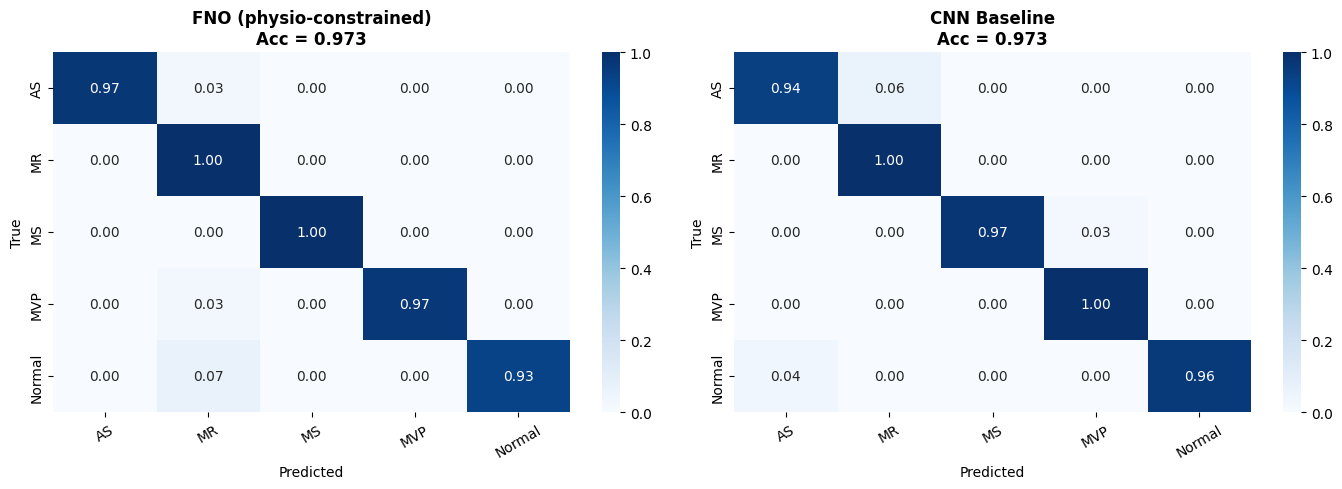

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, p, l, title in [
    (axes[0], preds_fno, labels_fno,
     f'FNO (physio-constrained)\nAcc = {acc_fno:.3f}'),
    (axes[1], preds_cnn, labels_cnn,
     f'CNN Baseline\nAcc = {acc_cnn:.3f}'),
]:
    cm = confusion_matrix(l, p, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', ax=ax,
                xticklabels=CONFIG['class_names'],
                yticklabels=CONFIG['class_names'],
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Learned Frequency Mask

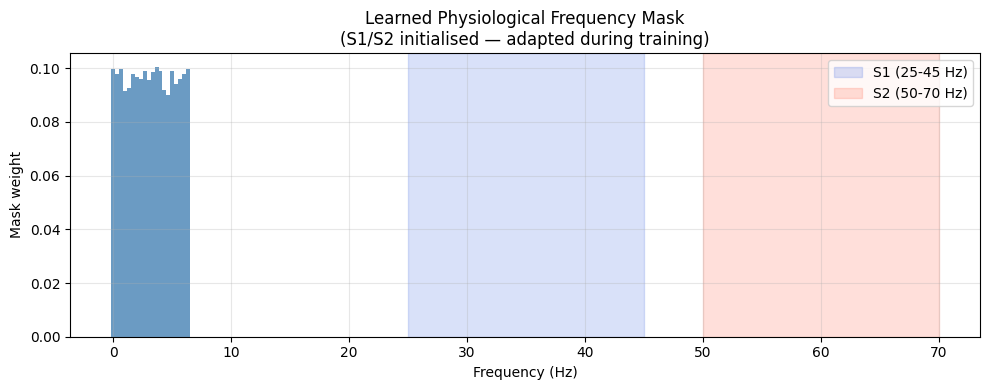

S1 band mean weight : nan
S2 band mean weight : nan
Other mean weight   : 0.097


In [17]:
mask  = model_fno.freq_mask.get_mask()
freqs = np.fft.rfftfreq(CONFIG['signal_length'],
                         1.0/CONFIG['sample_rate'])[:CONFIG['fno_modes']]
dfreq = freqs[1] - freqs[0] if len(freqs) > 1 else 1.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freqs, mask, width=dfreq, color='steelblue', alpha=0.8)
ax.axvspan(*CONFIG['s1_band'], alpha=0.2, color='royalblue',
            label='S1 (25-45 Hz)')
ax.axvspan(*CONFIG['s2_band'], alpha=0.2, color='tomato',
            label='S2 (50-70 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Mask weight')
ax.set_title('Learned Physiological Frequency Mask\n'
             '(S1/S2 initialised — adapted during training)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/learned_freq_mask.png', dpi=150, bbox_inches='tight')
plt.show()

s1  = (freqs >= CONFIG['s1_band'][0]) & (freqs <= CONFIG['s1_band'][1])
s2  = (freqs >= CONFIG['s2_band'][0]) & (freqs <= CONFIG['s2_band'][1])
oth = ~(s1 | s2)
print(f'S1 band mean weight : {mask[s1].mean():.3f}')
print(f'S2 band mean weight : {mask[s2].mean():.3f}')
print(f'Other mean weight   : {mask[oth].mean():.3f}')

## 11. Latent Space (t-SNE)

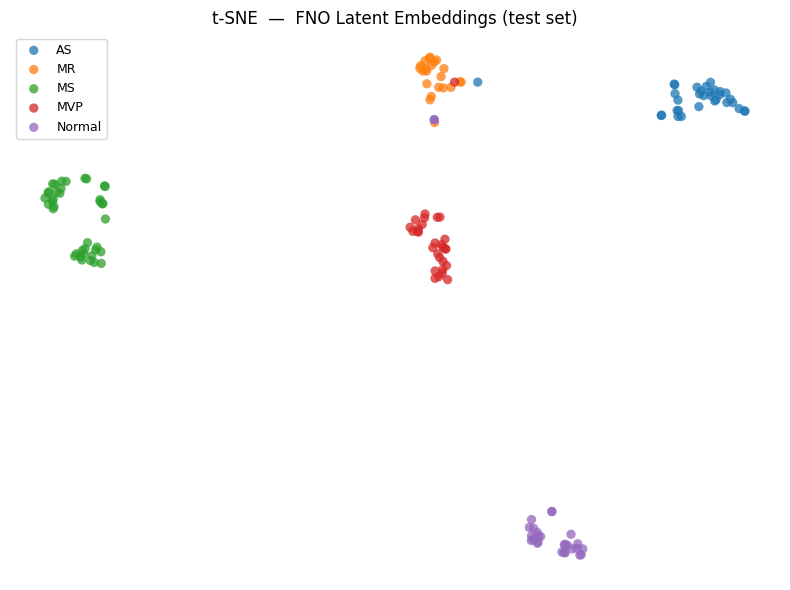

In [18]:
from sklearn.manifold import TSNE

model_fno.eval()
embs, tlabels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        _, emb = model_fno(xb.to(DEVICE))
        embs.append(emb.cpu().numpy())
        tlabels.extend(yb.numpy())

embs    = np.concatenate(embs)
tlabels = np.array(tlabels)
emb_2d  = TSNE(n_components=2, perplexity=15,
                random_state=42).fit_transform(embs)

fig, ax = plt.subplots(figsize=(8, 6))
for cls in range(CONFIG['n_classes']):
    idx = tlabels == cls
    ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1],
               label=CONFIG['class_names'][cls],
               alpha=0.75, s=45, edgecolors='none')
ax.set_title('t-SNE  —  FNO Latent Embeddings (test set)')
ax.legend(fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig('figures/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary

In [19]:
print('\n' + '='*60)
print(' RESULTS SUMMARY')
print('='*60)
print(f' {"Model":<38} {"Test Acc":>8}')
print('-'*60)
print(f' {"CNN Baseline (Mel spectrogram)":<38} {acc_cnn:>8.4f}')
print(f' {"FNO (physio-constrained)":<38} {acc_fno:>8.4f}')
print('='*60)
print()
print(f' Classes  : AS / MR / MS / MVP / Normal')
print(f' N total  : {len(dataset)}')
print(f' SR       : {CONFIG["sample_rate"]} Hz (auto-detected)')
print(f' Window   : {CONFIG["signal_length"]/CONFIG["sample_rate"]:.1f} s '
      f'({CONFIG["signal_length"]} samples)')
print()
print(' Physiological constraints in FNO:')
print('  [1] Periodicity loss     energy near HR fundamental + harmonics')
print('  [2] Freq. hierarchy      S1 energy >= S2 energy  (hinge form)')
print('  [3] Physio freq. mask    learnable, S1/S2-band initialised')


 RESULTS SUMMARY
 Model                                  Test Acc
------------------------------------------------------------
 CNN Baseline (Mel spectrogram)           0.9733
 FNO (physio-constrained)                 0.9733

 Classes  : AS / MR / MS / MVP / Normal
 N total  : 1000
 SR       : 22050 Hz (auto-detected)
 Window   : 3.0 s (66150 samples)

 Physiological constraints in FNO:
  [1] Periodicity loss     energy near HR fundamental + harmonics
  [2] Freq. hierarchy      S1 energy >= S2 energy  (hinge form)
  [3] Physio freq. mask    learnable, S1/S2-band initialised
